In [1]:
import sys, os

if os.path.abspath('MedViTV2') not in sys.path:
    sys.path.insert(0, os.path.abspath('MedViTV2'))

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import gc

from MedViTV2.MedViT import MedViT_small, MedViT_base

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Using device: cuda


In [2]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder('dataset_split/train', transform=train_transforms)
val_dataset   = datasets.ImageFolder('dataset_split/val',   transform=test_transforms)
test_dataset  = datasets.ImageFolder('dataset_split/test',  transform=test_transforms)

BATCH_SIZE = 12

loader_train = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
loader_val   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
loader_test  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

classes     = train_dataset.classes
num_classes = len(classes)
print(f"Classes ({num_classes}): {classes}")
print(f"Train batches: {len(loader_train)}  Val: {len(loader_val)}  Test: {len(loader_test)}")

Classes (5): ['F0', 'F1', 'F2', 'F3', 'F4']
Train batches: 369  Val: 79  Test: 80


In [3]:
criterion = nn.CrossEntropyLoss()
os.makedirs('checkpoints_v2', exist_ok=True)

def train_model(model: nn.Module, optimizer, num_epochs: int = 30, name: str = 'model') -> nn.Module:
    since = time.time()
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = loader_train
            else:
                model.eval()
                loader = loader_val

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc  = running_corrects.double() / len(loader.dataset)
            print(f"{phase} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        if (epoch + 1) % 5 == 0:
            ckpt = f'checkpoints_v2/{name}_epoch{epoch + 1}.pth'
            torch.save(model.state_dict(), ckpt)
            print(f"Checkpoint saved: {ckpt}")

    elapsed = time.time() - since
    print(f"Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    return model

In [4]:
model_small = MedViT_small(num_classes=num_classes).to(device)
optimizer_small = optim.Adam(model_small.parameters(), lr=0.0001)

print("=== Training MedViT-V2-small ===")
model_small = train_model(model_small, optimizer_small, num_epochs=20, name='medvit_v2_small')
torch.save(model_small.state_dict(), 'medvit_v2_small.pth')
print("Saved medvit_v2_small.pth")

torch.cuda.empty_cache()
del model_small, optimizer_small
gc.collect()
torch.cuda.empty_cache()

initialize_weights...
=== Training MedViT-V2-small ===
Epoch 1/20
----------
train Loss: 1.2299  Acc: 0.4723
val Loss: 1.2063  Acc: 0.4958
Epoch 2/20
----------
train Loss: 1.0793  Acc: 0.5372
val Loss: 0.9537  Acc: 0.5687
Epoch 3/20
----------
train Loss: 0.8764  Acc: 0.6288
val Loss: 0.8586  Acc: 0.6512
Epoch 4/20
----------
train Loss: 0.7737  Acc: 0.6728
val Loss: 0.6421  Acc: 0.7537
Epoch 5/20
----------
train Loss: 0.7024  Acc: 0.6966
val Loss: 0.8116  Acc: 0.6247
Checkpoint saved: checkpoints_v2/medvit_v2_small_epoch5.pth
Epoch 6/20
----------
train Loss: 0.6425  Acc: 0.7262
val Loss: 0.5487  Acc: 0.7759
Epoch 7/20
----------
train Loss: 0.5861  Acc: 0.7547
val Loss: 0.6236  Acc: 0.7230
Epoch 8/20
----------
train Loss: 0.5494  Acc: 0.7746
val Loss: 0.5432  Acc: 0.7738
Epoch 9/20
----------
train Loss: 0.5418  Acc: 0.7782
val Loss: 3.4687  Acc: 0.3615
Epoch 10/20
----------
train Loss: 0.4989  Acc: 0.7854
val Loss: 0.4227  Acc: 0.8214
Checkpoint saved: checkpoints_v2/medvit_v2_s

In [5]:
model_base = MedViT_base(num_classes=num_classes).to(device)
optimizer_base = optim.Adam(model_base.parameters(), lr=0.0001)

print("=== Training MedViT-V2-base ===")
model_base = train_model(model_base, optimizer_base, num_epochs=20, name='medvit_v2_base')
torch.save(model_base.state_dict(), 'medvit_v2_base.pth')
print("Saved medvit_v2_base.pth")

torch.cuda.empty_cache()
try:
    del model_base, optimizer_base
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

initialize_weights...
=== Training MedViT-V2-base ===
Epoch 1/20
----------
train Loss: 1.2447  Acc: 0.4734
val Loss: 1.1743  Acc: 0.5127
Epoch 2/20
----------
train Loss: 1.1605  Acc: 0.4974
val Loss: 1.0214  Acc: 0.5529
Epoch 3/20
----------
train Loss: 1.0235  Acc: 0.5596
val Loss: 1.4415  Acc: 0.4366
Epoch 4/20
----------
train Loss: 0.8994  Acc: 0.6084
val Loss: 0.7718  Acc: 0.6607
Epoch 5/20
----------
train Loss: 0.8066  Acc: 0.6597
val Loss: 0.6186  Acc: 0.7347
Checkpoint saved: checkpoints_v2/medvit_v2_base_epoch5.pth
Epoch 6/20
----------
train Loss: 0.7640  Acc: 0.6704
val Loss: 0.6044  Acc: 0.7347
Epoch 7/20
----------
train Loss: 0.6797  Acc: 0.7081
val Loss: 2.3759  Acc: 0.4175
Epoch 8/20
----------
train Loss: 0.6575  Acc: 0.7210
val Loss: 0.6145  Acc: 0.7304
Epoch 9/20
----------
train Loss: 0.6293  Acc: 0.7350
val Loss: 0.4464  Acc: 0.8087
Epoch 10/20
----------
train Loss: 0.5914  Acc: 0.7545
val Loss: 0.6974  Acc: 0.7230
Checkpoint saved: checkpoints_v2/medvit_v2_bas

In [6]:
def evaluate_model(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc  = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    return {
        'y_true': y_true, 'y_pred': y_pred,
        'accuracy': acc, 'precision_macro': prec,
        'recall_macro': rec, 'f1_macro': f1,
        'confusion_matrix': cm,
    }

In [7]:
results = {}
for variant, ModelClass in [('small', MedViT_small), ('base', MedViT_base)]:
    model = ModelClass(num_classes=num_classes)
    model.load_state_dict(torch.load(f'medvit_v2_{variant}.pth'))
    model = model.to(device)

    results[variant] = evaluate_model(model, loader_test)
    print(f"\n=== MedViT-V2-{variant} — Classification Report (test) ===")
    print(classification_report(
        results[variant]['y_true'],
        results[variant]['y_pred'],
        target_names=classes,
        zero_division=0,
    ))
    
    del model
    gc.collect()
    torch.cuda.empty_cache()

initialize_weights...

=== MedViT-V2-small — Classification Report (test) ===
              precision    recall  f1-score   support

          F0       1.00      0.19      0.32       318
          F1       0.47      0.35      0.40       130
          F2       0.70      0.19      0.30       120
          F3       0.44      0.76      0.56       130
          F4       0.41      0.86      0.55       256

    accuracy                           0.47       954
   macro avg       0.60      0.47      0.43       954
weighted avg       0.65      0.47      0.42       954

initialize_weights...

=== MedViT-V2-base — Classification Report (test) ===
              precision    recall  f1-score   support

          F0       1.00      0.98      0.99       318
          F1       0.66      0.78      0.71       130
          F2       0.66      0.53      0.59       120
          F3       0.84      0.50      0.63       130
          F4       0.78      0.96      0.86       256

    accuracy                  

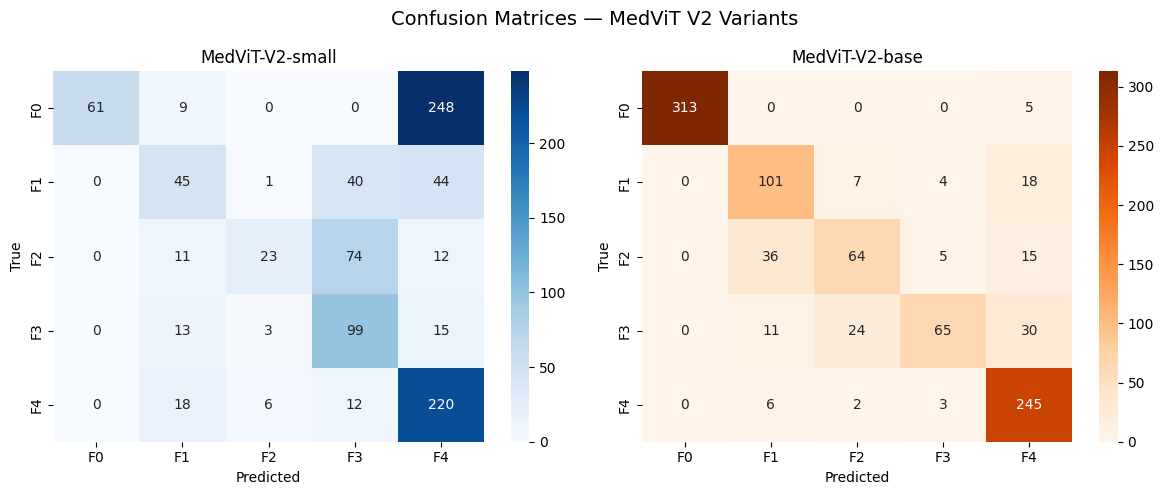

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmaps = ['Blues', 'Oranges']

for ax, (variant, cmap) in zip(axes, zip(['small', 'base'], cmaps)):
    sns.heatmap(
        results[variant]['confusion_matrix'],
        annot=True, fmt='d', cmap=cmap,
        xticklabels=classes, yticklabels=classes,
        ax=ax,
    )
    ax.set_title(f'MedViT-V2-{variant}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — MedViT V2 Variants', fontsize=14)
plt.tight_layout()
plt.show()

initialize_weights...


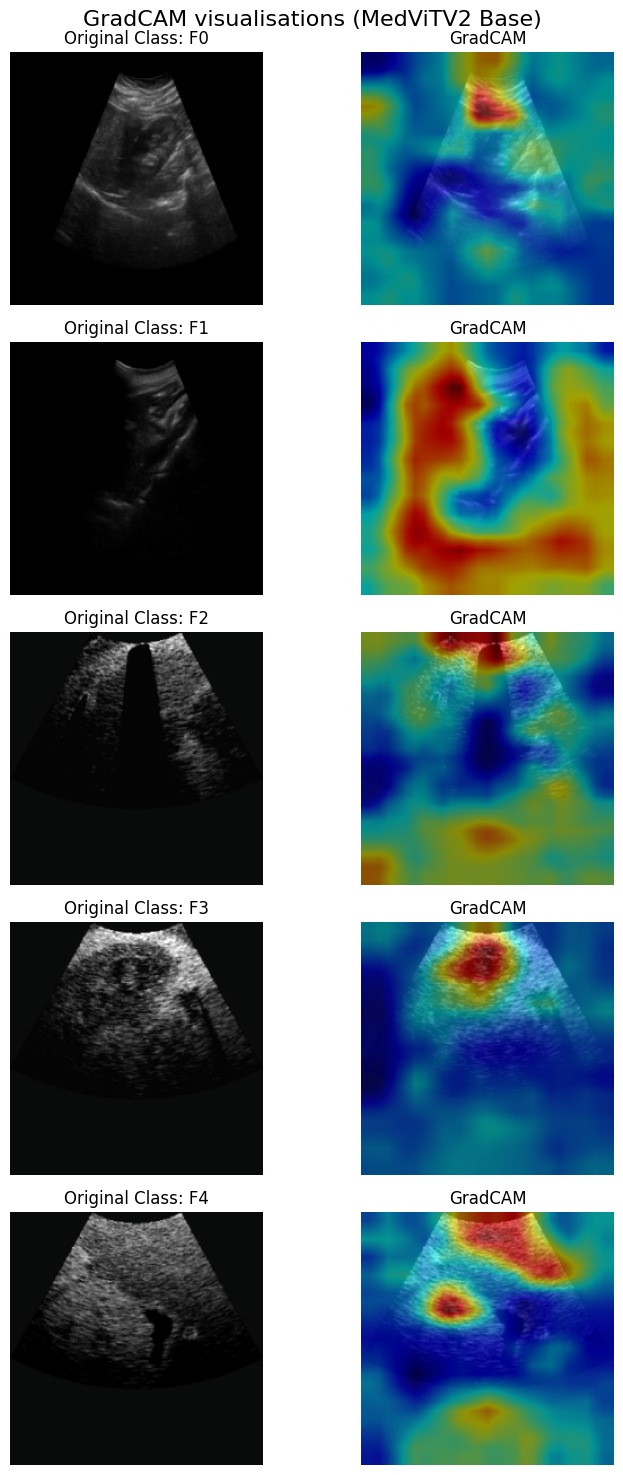

In [9]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

model = MedViT_base(num_classes=num_classes)
try:
    model.load_state_dict(torch.load('medvit_v2_base.pth'))
except Exception as e:
    print("Could not load base model weights:", e)
model = model.to(device)
model.eval()

try:
    target_layers = [model.features[-1].norm2, model.features[-4].norm2, model.norm]
except AttributeError:
    print("Trying alternative target layers...")
    try:
        target_layers = [model.features[-1]]
    except:
        target_layers = []

if target_layers:
    cam = GradCAM(model=model, target_layers=target_layers)

    fig, axes = plt.subplots(num_classes, 2, figsize=(8, 3 * num_classes))
    fig.suptitle('GradCAM visualisations (MedViTV2 Base)', fontsize=16)

    class_visited = set()

    for inputs, labels in loader_test:
        if len(class_visited) == num_classes:
            break
            
        for i in range(inputs.size(0)):
            label = labels[i].item()
            if label not in class_visited:
                class_visited.add(label)
                
                img_tensor = inputs[i:i+1]
                
                rgb_img = img_tensor[0].cpu().numpy().transpose(1, 2, 0)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                rgb_img = std * rgb_img + mean
                rgb_img = np.clip(rgb_img, 0, 1)
                
                grayscale_cam = cam(input_tensor=img_tensor.to(device))
                grayscale_cam = grayscale_cam[0, :]
                
                cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
                
                axes[label, 0].imshow(rgb_img)
                axes[label, 0].set_title(f'Original Class: {classes[label]}')
                axes[label, 0].axis('off')
                
                axes[label, 1].imshow(cam_image)
                axes[label, 1].set_title(f'GradCAM')
                axes[label, 1].axis('off')
                
                if len(class_visited) == num_classes:
                    break

    plt.tight_layout()
    plt.show()
else:
    print("Target layers not properly found for GradCAM!")

In [10]:
torch.cuda.empty_cache()
try:
    del model, cam
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()